# Notebook 02 — Análise de Robustez

Esse notebook é a continuação do notebook 01 (treinamento e avaliação dos modelos). Aqui o objetivo é testar o quão confiáveis são os resultados que obtivemos, usando validação cruzada, curvas de aprendizado e uma análise dos erros do melhor modelo (Naive Bayes).

O que tem aqui:
- Validação cruzada com k=5 e k=10 pra Naive Bayes e Regressão Logística
- Curvas de aprendizado pra ver se os modelos se beneficiam de mais dados
- Análise de erros: quais frases o modelo erra, de qual fonte (ChatGPT/Claude/Gemini) e por quê

In [46]:
import os, subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, learning_curve, train_test_split
from sklearn.metrics import classification_report

sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

# detectar se ta rodando no colab ou local
NO_COLAB = os.path.exists('/content')

if NO_COLAB:
    repo_dir = '/content/tcc-analise-sentimento'
    if os.path.exists(repo_dir):
        subprocess.run(['git', '-C', repo_dir, 'pull'], check=True)
    else:
        subprocess.run(['git', 'clone',
            'https://github.com/ROMAUSKI/tcc-analise-sentimento.git', repo_dir], check=True)
    base_dir = repo_dir
else:
    base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

caminho_csv = os.path.join(base_dir, 'dados', 'processado', 'synthetic_dataset.csv')
df = pd.read_csv(caminho_csv)
df = df.dropna(subset=['frase_limpa'])
X = df['frase_limpa']
y = df['classe']

dir_resultados = os.path.join(base_dir, 'resultados')
os.makedirs(dir_resultados, exist_ok=True)

print(f'Dataset carregado: {len(df)} amostras')
print(y.value_counts())

Dataset carregado: 1798 amostras
classe
Positiva    600
Neutra      600
Negativa    598
Name: count, dtype: int64


In [47]:
# validacao cruzada com accuracy e f1
def criar_pipeline(clf):
    return Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', clf)])

experimentos = [
    ('Naive Bayes (k=5)',  MultinomialNB(), 5),
    ('Naive Bayes (k=10)', MultinomialNB(), 10),
    ('Reg. Logística (k=5)',  LogisticRegression(max_iter=1000), 5),
    ('Reg. Logística (k=10)', LogisticRegression(max_iter=1000), 10),
]

resultados = []
for nome, clf, k in experimentos:
    acc = cross_val_score(criar_pipeline(clf), X, y, cv=k, scoring='accuracy')
    f1  = cross_val_score(criar_pipeline(clf), X, y, cv=k, scoring='f1_weighted')
    resultados.append({'Modelo': nome, 'k': k,
                       'Acc Média': acc.mean(), 'Acc DP': acc.std(),
                       'F1 Média': f1.mean(), 'F1 DP': f1.std(),
                       'Scores Acc': acc, 'Scores F1': f1})
    print(f'{nome}: Acc={acc.mean()*100:.2f}% (±{acc.std()*100:.2f}) | F1={f1.mean()*100:.2f}% (±{f1.std()*100:.2f})')

# montar tabela
linhas = []
for r in resultados:
    linhas.append({
        'Modelo': r['Modelo'], 'k': r['k'],
        'Accuracy (%)': f"{r['Acc Média']*100:.2f} ± {r['Acc DP']*100:.2f}",
        'F1-Score (%)': f"{r['F1 Média']*100:.2f} ± {r['F1 DP']*100:.2f}"
    })
df_cv = pd.DataFrame(linhas)
df_cv

Naive Bayes (k=5): Acc=89.10% (±0.72) | F1=89.11% (±0.73)
Naive Bayes (k=10): Acc=89.10% (±1.81) | F1=89.11% (±1.82)
Reg. Logística (k=5): Acc=87.04% (±1.52) | F1=87.00% (±1.54)
Reg. Logística (k=10): Acc=87.60% (±2.70) | F1=87.53% (±2.78)


,Modelo,k,Accuracy (%),F1-Score (%)
0,Naive Bayes (k=5),5,89.10 ± 0.72,89.11 ± 0.73
1,Naive Bayes (k=10),10,89.10 ± 1.81,89.11 ± 1.82
2,Reg. Logística (k=5),5,87.04 ± 1.52,87.00 ± 1.54
3,Reg. Logística (k=10),10,87.60 ± 2.70,87.53 ± 2.78


In [48]:
df_cv.to_csv(os.path.join(dir_resultados, 'validacao_cruzada.csv'), index=False)
print('salvo em resultados/validacao_cruzada.csv')

salvo em resultados/validacao_cruzada.csv


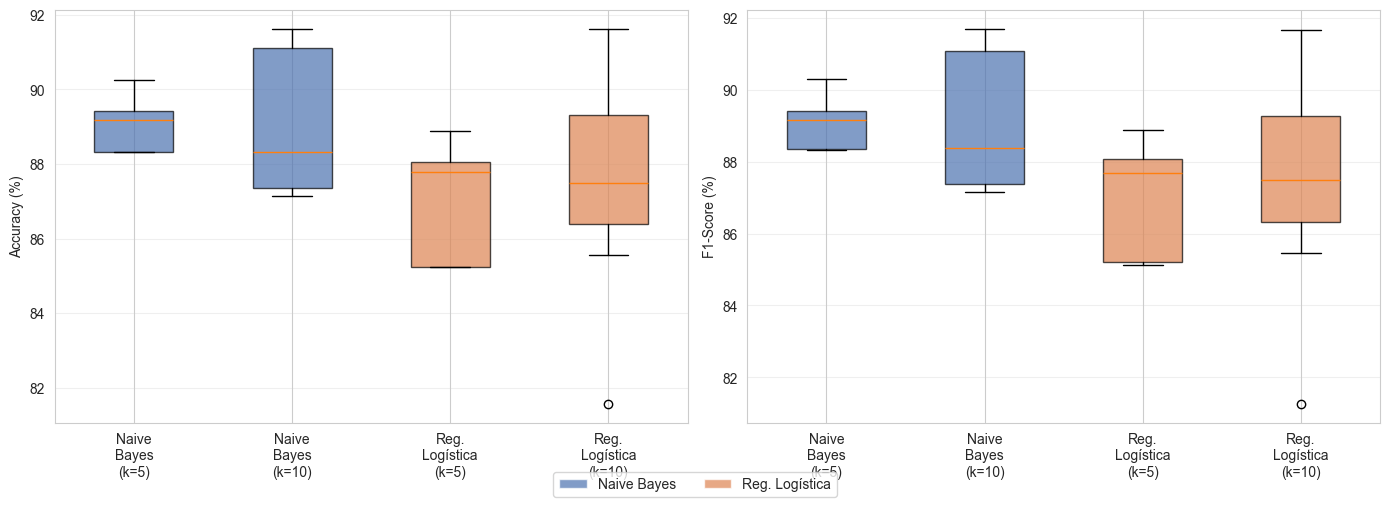

In [49]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
cores = ['#4C72B0', '#4C72B0', '#DD8452', '#DD8452']

# boxplot accuracy
dados_acc = {r['Modelo']: r['Scores Acc'] * 100 for r in resultados}
bp1 = ax1.boxplot(dados_acc.values(),
                  labels=[n.replace(' ', '\n') for n in dados_acc.keys()],
                  patch_artist=True, widths=0.5)
for patch, cor in zip(bp1['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax1.set_ylabel('Accuracy (%)')
ax1.grid(axis='y', alpha=0.3)

# boxplot f1
dados_f1 = {r['Modelo']: r['Scores F1'] * 100 for r in resultados}
bp2 = ax2.boxplot(dados_f1.values(),
                  labels=[n.replace(' ', '\n') for n in dados_f1.keys()],
                  patch_artist=True, widths=0.5)
for patch, cor in zip(bp2['boxes'], cores):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax2.set_ylabel('F1-Score (%)')
ax2.grid(axis='y', alpha=0.3)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(facecolor='#4C72B0', alpha=0.7, label='Naive Bayes'),
                     Patch(facecolor='#DD8452', alpha=0.7, label='Reg. Logística')],
           loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
fig.savefig(os.path.join(dir_resultados, 'boxplot_validacao_cruzada.png'), dpi=150, bbox_inches='tight')
plt.show()

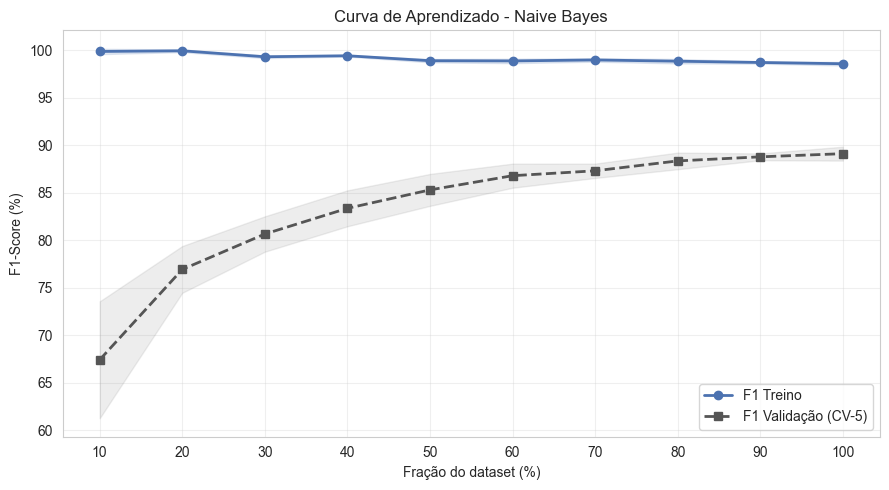

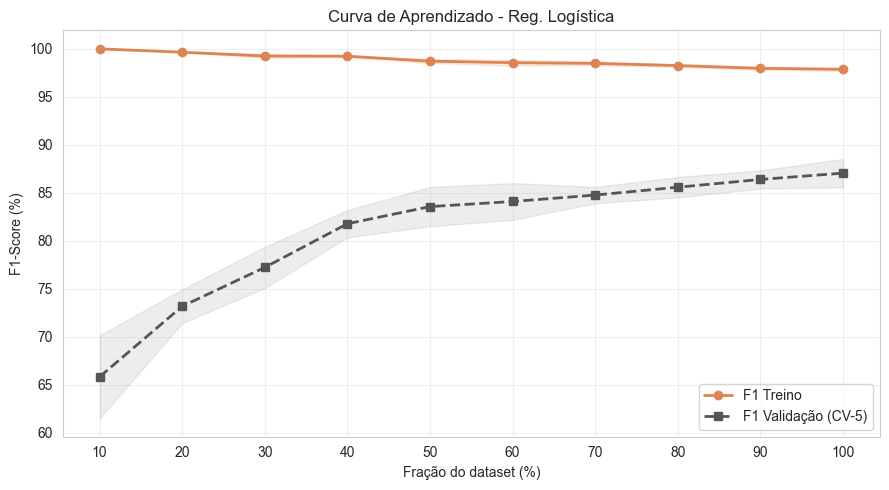

In [50]:
# curvas de aprendizado
fracs = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

modelos_lc = [
    ('Naive Bayes', MultinomialNB(), '#4C72B0', 'curva_aprendizado_nb.png'),
    ('Reg. Logística', LogisticRegression(max_iter=1000), '#DD8452', 'curva_aprendizado_lr.png'),
]

for nome, clf, cor, arquivo in modelos_lc:
    pipe = Pipeline([('tfidf', TfidfVectorizer(max_features=5000)), ('clf', clf)])
    sizes, tr_scores, val_scores = learning_curve(
        pipe, X, y, train_sizes=fracs, cv=5, scoring='f1_weighted', n_jobs=-1, random_state=42)

    tr_mean = tr_scores.mean(axis=1) * 100
    val_mean = val_scores.mean(axis=1) * 100
    tr_std = tr_scores.std(axis=1) * 100
    val_std = val_scores.std(axis=1) * 100
    pct = [f * 100 for f in fracs]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(pct, tr_mean, 'o-', color=cor, label='F1 Treino', linewidth=2)
    ax.fill_between(pct, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color=cor)
    ax.plot(pct, val_mean, 's--', color='#555', label='F1 Validação (CV-5)', linewidth=2)
    ax.fill_between(pct, val_mean - val_std, val_mean + val_std, alpha=0.10, color='#555')
    ax.set_title(f'Curva de Aprendizado - {nome}')
    ax.set_xlabel('Fração do dataset (%)')
    ax.set_ylabel('F1-Score (%)')
    ax.set_xticks(pct)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(dir_resultados, arquivo), dpi=150, bbox_inches='tight')
    plt.show()

## Curvas de aprendizado

O Naive Bayes converge rápido, a partir de uns 50-60% do dataset a curva de validação já estabiliza e o overfitting é praticamente zero. Ou seja, adicionar mais dados sintéticos parecidos provavelmente não vai melhorar muito.

A Regressão Logística demora mais pra convergir (lá pelos 70-80%) e tem uma diferença maior entre treino e validação, mas essa diferença vai diminuindo conforme o dataset cresce. Provavelmente se beneficiaria de mais dados.

No geral o NB é mais estável entre folds e converge mais rápido, o que faz sentido pro tamanho do dataset que temos. A LR oscila mais mas tende a se aproximar do NB com mais dados.

In [51]:
# treinar NB e identificar erros no teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

tfidf = TfidfVectorizer()
nb_model = MultinomialNB()
nb_model.fit(tfidf.fit_transform(X_train), y_train)
y_pred = nb_model.predict(tfidf.transform(X_test))

print(classification_report(y_test, y_pred))

df_test = df.loc[X_test.index].copy()
df_test['predita'] = y_pred
df_test['acertou'] = df_test['classe'] == df_test['predita']
erros = df_test[~df_test['acertou']]
print(f'\nErros: {len(erros)}/{len(df_test)} ({len(erros)/len(df_test)*100:.1f}%)')

              precision    recall  f1-score   support

    Negativa       0.86      0.90      0.88       120
      Neutra       0.93      0.89      0.91       120
    Positiva       0.87      0.87      0.87       120

    accuracy                           0.89       360
   macro avg       0.89      0.89      0.89       360
weighted avg       0.89      0.89      0.89       360


Erros: 41/360 (11.4%)


In [52]:
# erros por fonte
print('Erros por IA geradora:')
for fonte in sorted(df_test['fonte'].unique()):
    total = len(df_test[df_test['fonte'] == fonte])
    n_erros = len(erros[erros['fonte'] == fonte])
    print(f'  {fonte}: {n_erros}/{total} ({n_erros/total*100:.1f}%)')

# confusoes mais comuns
print('\nConfusões mais comuns:')
confusoes = erros.groupby(['classe', 'predita']).size().sort_values(ascending=False)
for (real, pred), n in confusoes.items():
    print(f'  {real} -> {pred}: {n}')

Erros por IA geradora:
  ChatGPT: 10/115 (8.7%)
  Claude: 14/112 (12.5%)
  Gemini: 17/133 (12.8%)

Confusões mais comuns:
  Positiva -> Negativa: 13
  Neutra -> Positiva: 8
  Negativa -> Positiva: 7
  Negativa -> Neutra: 5
  Neutra -> Negativa: 5
  Positiva -> Neutra: 3


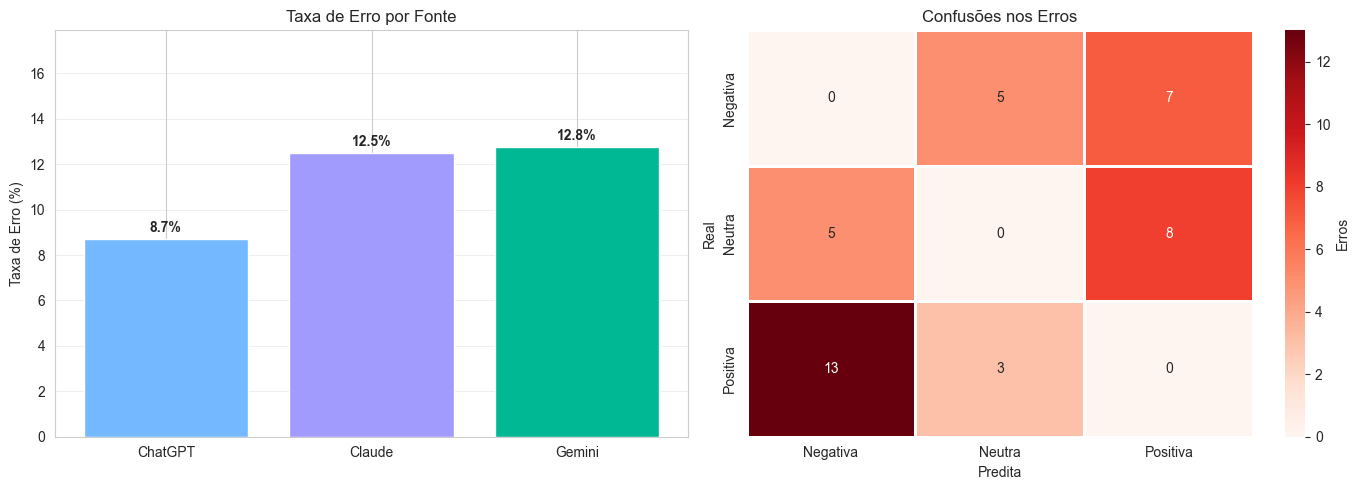

In [53]:
from sklearn.metrics import confusion_matrix

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# erro por fonte
fontes = sorted(df_test['fonte'].unique())
cores_fonte = {'ChatGPT': '#74b9ff', 'Claude': '#a29bfe', 'Gemini': '#00b894'}
taxas = []
for f in fontes:
    total = len(df_test[df_test['fonte'] == f])
    n_err = len(erros[erros['fonte'] == f])
    taxas.append(n_err / total * 100)

bars = ax1.bar(fontes, taxas, color=[cores_fonte[f] for f in fontes])
for bar, taxa in zip(bars, taxas):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{taxa:.1f}%', ha='center', fontweight='bold')
ax1.set_title('Taxa de Erro por Fonte')
ax1.set_ylabel('Taxa de Erro (%)')
ax1.set_ylim(0, max(taxas) * 1.4)
ax1.grid(axis='y', alpha=0.3)

# heatmap so com os erros
classes = ['Negativa', 'Neutra', 'Positiva']
cm = confusion_matrix(erros['classe'], erros['predita'], labels=classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=classes, yticklabels=classes,
            linewidths=1, cbar_kws={'label': 'Erros'})
ax2.set_title('Confusões nos Erros')
ax2.set_xlabel('Predita')
ax2.set_ylabel('Real')

plt.tight_layout()
fig.savefig(os.path.join(dir_resultados, 'analise_erros_graficos.png'), dpi=150, bbox_inches='tight')
plt.show()

In [54]:
# alguns exemplos de erros (variando tipo de confusao e fonte)
exemplos = []
for (real, pred), grupo in erros.groupby(['classe', 'predita']):
    for fonte in grupo['fonte'].unique():
        if len(exemplos) < 15:
            exemplos.append(grupo[grupo['fonte'] == fonte].iloc[0])

for i, row in enumerate(exemplos):
    print(f"[{i+1:02d}] {row['fonte']} | {row['classe']} -> {row['predita']}")
    print(f'     "{row["frase"]}"')
    print()

# salvar em csv
df_ex = pd.DataFrame(exemplos)[['frase', 'classe', 'predita', 'fonte']]
df_ex.to_csv(os.path.join(dir_resultados, 'analise_erros.csv'), index=False, encoding='utf-8-sig')
print(f'Salvo: resultados/analise_erros.csv ({len(df_ex)} exemplos)')

[01] Gemini | Negativa -> Neutra
     "A representação dos temas abordados foi superficial e problemática."

[02] ChatGPT | Negativa -> Neutra
     "A história é um clichê atrás do outro."

[03] Claude | Negativa -> Neutra
     "A produção é um insulto aos espectadores e ao próprio meio cinematográfico como forma de arte."

[04] Gemini | Negativa -> Positiva
     "A série começou bem, mas a qualidade caiu drasticamente a cada temporada."

[05] Claude | Negativa -> Positiva
     "Personagens agem completamente diferente em cada cena dependendo do que o roteiro precisa no momento."

[06] ChatGPT | Neutra -> Negativa
     "O gênero suspense mantém o público em expectativa constante."

[07] Gemini | Neutra -> Negativa
     "A série 'Arrested Development' é conhecida por seu humor complexo."

[08] ChatGPT | Neutra -> Positiva
     "O storyboard ilustra visualmente as cenas planejadas."

[09] Gemini | Neutra -> Positiva
     "A série 'Veep' é uma sátira política."

[10] Claude | Positiva -> 

## Análise de erros

O Naive Bayes errou 41 de 360 amostras no teste (11,4%). A confusão mais comum foi Positiva classificada como Negativa (13 erros), o que faz sentido porque muitas frases positivas usam negações tipo "sem nunca decepcionar" ou "não subestima", e o TF-IDF trata essas palavras de forma isolada sem entender a inversão.

Sobre as fontes, o ChatGPT teve a menor taxa de erro (8,7%) e o Gemini a maior (12,8%). Pelas frases que vi nos exemplos, o Gemini tende a misturar vocabulário descritivo com sentimento mais sutil, enquanto o ChatGPT é bem mais direto.

Também notei que frases neutras com palavras tipo "desastre nuclear" ou "profundidade" acabam sendo classificadas como positivas ou negativas. Isso faz sentido porque o bag-of-words não tem como saber que a palavra tá sendo usada num contexto descritivo e não emocional. Ponto interessante para levar em consideração.

## Texto para o artigo

### Resultados — Validação Cruzada

Para avaliar a estabilidade dos modelos e verificar se os resultados obtidos no split treino/teste não foram influenciados por uma divisão favorável dos dados, foi aplicada validação cruzada estratificada com k=5 e k=10 para ambos os classificadores.

O Naive Bayes apresentou F1-Score médio de 89,11% com desvio padrão de 0,73% para k=5, e 89,11% com desvio padrão de 1,82% para k=10. A Regressão Logística obteve 87,00% (±1,54%) com k=5 e 87,53% (±2,78%) com k=10. Observa-se que o Naive Bayes mantém desempenho praticamente idêntico independentemente do número de folds, com desvio padrão consistentemente menor, o que indica alta estabilidade. A Regressão Logística apresentou variância maior, especialmente com k=10, onde a menor quantidade de amostras por fold amplia as diferenças entre as partições.

É relevante notar que os valores de F1 obtidos na validação cruzada (89,11% para NB) são ligeiramente inferiores ao resultado do split simples (90,30%), o que é esperado já que a validação cruzada fornece uma estimativa menos otimista e mais robusta do desempenho real do modelo.

### Resultados — Curvas de Aprendizado

As curvas de aprendizado foram construídas variando a fração do dataset de treino de 10% a 100%, em incrementos de 10%, utilizando validação cruzada com 5 folds e F1-Score ponderado como métrica. O objetivo foi avaliar se os modelos se beneficiariam de mais dados de treinamento e identificar possíveis sinais de overfitting ou underfitting.

O Naive Bayes demonstrou convergência rápida: o F1 de validação sobe expressivamente entre 10% e 40% do dataset e estabiliza a partir de aproximadamente 50-60%. A diferença entre F1 de treino e F1 de validação permaneceu pequena ao longo de toda a curva, indicando que o modelo não sofre de overfitting significativo. A presença de platô a partir de 60-70% sugere que a adição de mais dados sintéticos do mesmo tipo teria retorno marginal para este modelo.

A Regressão Logística apresentou convergência mais gradual, com ganhos distribuídos ao longo de todas as frações do dataset e tendência de estabilização apenas a partir de 70-80%. A diferença entre treino e validação, embora presente, diminui conforme mais dados são adicionados, o que é um comportamento saudável de generalização. A maior variância entre folds sugere que a LR pode ser mais sensível à composição dos dados de treino e potencialmente se beneficiaria de um dataset maior.

### Resultados — Análise de Erros

Para compreender as limitações do melhor modelo, foi conduzida uma análise qualitativa dos erros do Naive Bayes sobre o conjunto de teste. O modelo errou 41 de 360 amostras, resultando em uma taxa de erro de 11,4%.

A análise por tipo de confusão revelou que a classificação incorreta mais frequente foi de frases positivas como negativas (13 erros, 31,7% do total de erros). A inspeção manual desses casos indicou que o padrão principal é o uso de negações compostas em construções elogiosas, como "sem nunca decepcionar" e "não subestima ninguém". Como o TF-IDF trata cada palavra de forma independente, os termos "sem", "nunca" e "não" contribuem com peso negativo mesmo quando a frase como um todo expressa sentimento positivo. Essa é uma limitação conhecida de representações bag-of-words.

A análise por fonte geradora mostrou diferenças relevantes na taxa de erro: o ChatGPT apresentou 8,7% (10/115 amostras), o Claude 12,5% (14/112) e o Gemini 12,8% (17/133). As frases do Gemini frequentemente combinam vocabulário descritivo com sentimento implícito, dificultando a classificação. O Claude produz mais construções com negação dupla e inversão, que confundem o classificador. O ChatGPT gera frases com sentimento mais explícito e vocabulário mais diretamente associado à polaridade, o que facilita a classificação pelo TF-IDF.

Um terceiro padrão observado foi a confusão entre frases neutras e classes polarizadas. Frases descritivas que contêm palavras com forte carga emocional fora de contexto opinativo — como "desastre nuclear" ou "profundidade emocional" — foram classificadas incorretamente, pois o modelo não distingue entre o uso descritivo e o uso emotivo dessas palavras.

Esses achados reforçam que a qualidade e o estilo dos dados sintéticos variam entre LLMs, e que a escolha do modelo gerador pode impactar diretamente o desempenho de classificadores treinados sobre esses dados.

### Discussão — Limitações

A principal limitação deste trabalho é que toda a avaliação foi conduzida sobre dados sintéticos. Embora os resultados demonstrem consistência interna — validação cruzada estável, curvas de aprendizado bem comportadas e análise de erros coerente —, não é possível afirmar que os modelos generalizariam para textos escritos por humanos. Dados sintéticos gerados por LLMs tendem a apresentar padrões de vocabulário e estrutura que diferem de textos orgânicos: frases mais bem formadas, menor presença de gírias e coloquialismos, e distribuição de vocabulário potencialmente mais uniforme.

Além disso, o uso exclusivo de modelos lineares (Naive Bayes e Regressão Logística) com representação TF-IDF limita a capacidade do sistema em capturar relações semânticas, negações compostas e contexto. Modelos baseados em word embeddings ou transformers poderiam mitigar parte das limitações identificadas na análise de erros, mas não foram incluídos no escopo deste trabalho por se tratar de uma avaliação de modelos baseline.

---

### Referências para consultar antes de escrever o artigo

Sobre validação cruzada e avaliação de modelos:
- Raschka, S. (2018). *Model Evaluation, Model Selection, and Algorithm Selection in Machine Learning*. arXiv:1811.12808. — fundamenta k-fold, stratified CV e métricas
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2ª ed.). Springer. Cap. 7 (Model Assessment and Selection). — referência clássica sobre bias-variance tradeoff e curvas de aprendizado

Sobre curvas de aprendizado:
- Perlich, C. (2010). *Learning Curves in Machine Learning*. Encyclopedia of Machine Learning. Springer. — explica interpretação de curvas e diagnóstico de overfitting/underfitting

Sobre análise de erros em NLP:
- Wu, T. et al. (2019). *Errudite: Scalable, Reproducible, and Testable Error Analysis*. ACL 2019. — framework de análise de erros, bom pra justificar a abordagem qualitativa

Sobre limitações de bag-of-words e TF-IDF:
- Jurafsky, D., & Martin, J. H. (2024). *Speech and Language Processing* (3ª ed., rascunho). Cap. 6 (Vector Semantics). — discute limitações de representações esparsas vs densas
- Goldberg, Y. (2017). *Neural Network Methods for Natural Language Processing*. Morgan & Claypool. Cap. 1-4. — contexto de por que embeddings superam bag-of-words

Sobre dados sintéticos e impacto da fonte geradora:
- Li, Y. et al. (2023). *Synthetic Data Generation with Large Language Models for Text Classification: Potential and Limitations*. EMNLP 2023. — compara dados de diferentes LLMs para classificação, diretamente relacionado
- Veselovsky, V., Ribeiro, M. H., & West, R. (2023). *Generating Faithful Synthetic Data with Large Language Models*. arXiv:2305.15041.
- Ye, J. et al. (2022). *ZeroGen: Efficient Zero-shot Learning via Dataset Generation*. EMNLP 2022. — geração de dados com LLMs pra treinar classificadores, contexto similar

Sobre análise de sentimentos em português:
- Souza, M. et al. (2011). *Construction of a Portuguese Opinion Lexicon from multiple resources*. STIL 2011. — léxico de sentimento em PT-BR
- Moreira, S. et al. (2013). *SentiLex-PT: A Sentiment Lexicon for Portuguese*. — outro recurso lexical pra PT, pode citar como trabalho relacionado